# **A. Global Lagrange interpolation**

In [ ]:
# import all the packages here

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# set the value of p to use for all the questions in sections A and B
p = 1
a = 0
b = 2 * p * np.pi

In [ ]:
## Lagrange interpolation
#
# INPUT:
# f scalar-valued function
# interval  interpolation interval [a,b]
# n interpolation order
#
# OUTPUT:
# coeff     centered coefficients of Lagrange interpolant


def lagrangeInterp(f, interval, n):
    # interval endpoints
    a, b = interval
    # define a linspace on the interval to use as input for np.polyfit
    nodes = np.linspace(a, b, n+1)
    # define the midpoint of the interval
    m = (a + b) / 2
    # compute the centered coefficients using np.polyfit
    nodes_m = nodes - m
    coeff = np.polyfit(nodes_m, f(nodes), n)

    return coeff


f = lambda x: np.sin(x / p)
interval = np.array([a, b])

### TEST ###
# verify the values of c0 and c1 comparing with those obtained in the tutorial

# add your test code here and check the coefficients you get
# ...
#

for n in range(2):
    print('For ' f'n={n+1},' 'the coefficients should be the following:')
    print(lagrangeInterp(f, interval, n+1))


For n=1,the coefficients should be the following:
[-3.89817183e-17 -1.22464680e-16]
For n=2,the coefficients should be the following:
[-2.48165326e-17 -3.89817183e-17  1.22464680e-16]


In [ ]:
## Evaluate interpolant
#   Yq = EVALUATEINTERPOLANT(C, I, Xq, N), with N=1, evaluates the Lagrange
#   interpolant defined by the coefficients C on the given interval I at the points
#   in the array Xq. C is an array of length n+1 (the indeces then being 0,...,n)
#   containing the polynomial coefficients in descending powers:
#
#      Yq[i] = C[0]*(Xq[i]-M)**n + C[1]*(Xq[i]-M)**(n-1) +...+ C[n-1]*(Xq[i]-M) + C[n],
#
#   where M is the midpoint of the interval
#      M = (I[0] + I[1]) / 2
#
#   Yq = EVALUATEINTERPOLANT(Cs, Is, Xq, N) evaluates the piecewise Lagrange
#   interpolants defined by the coefficients Cs(i, :) on the interval Is(i, :)
#   with N subintervals at the points in the array Xq.
#


def evaluateInterpolant(coeffs, intervals, xVals, N):
    fVals = np.zeros((np.size(xVals)))

    if N == 1:
        for i in range(np.size(coeffs) - 1):
            m = (intervals[0] + intervals[1]) / 2
            fVals = np.polyval(coeffs, xVals - m)
    else:
        for k in range(N):
            coeff_int = coeffs[k, :]
            I_int = intervals[k, :]
            x_int = xVals[(I_int[0] <= xVals) & (xVals <= I_int[1])]
            m = (I_int[0] + I_int[1]) / 2
            y = np.polyval(coeff_int, x_int - m)
            fVals[(I_int[0] <= xVals) & (xVals <= I_int[1])] = y

    return fVals


## discussion question A1

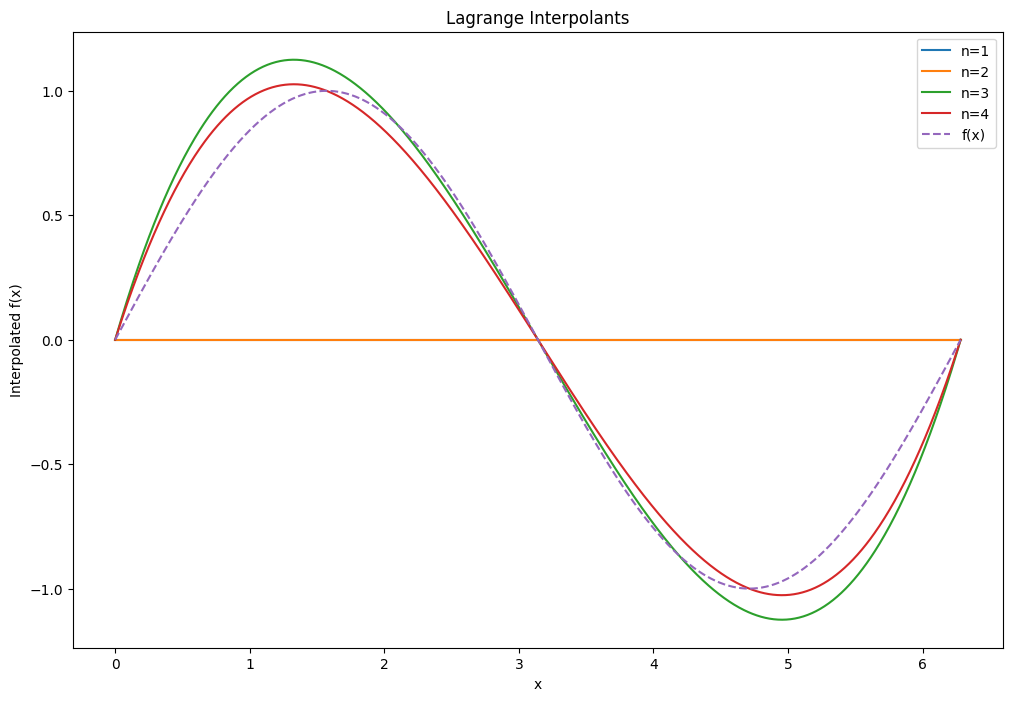

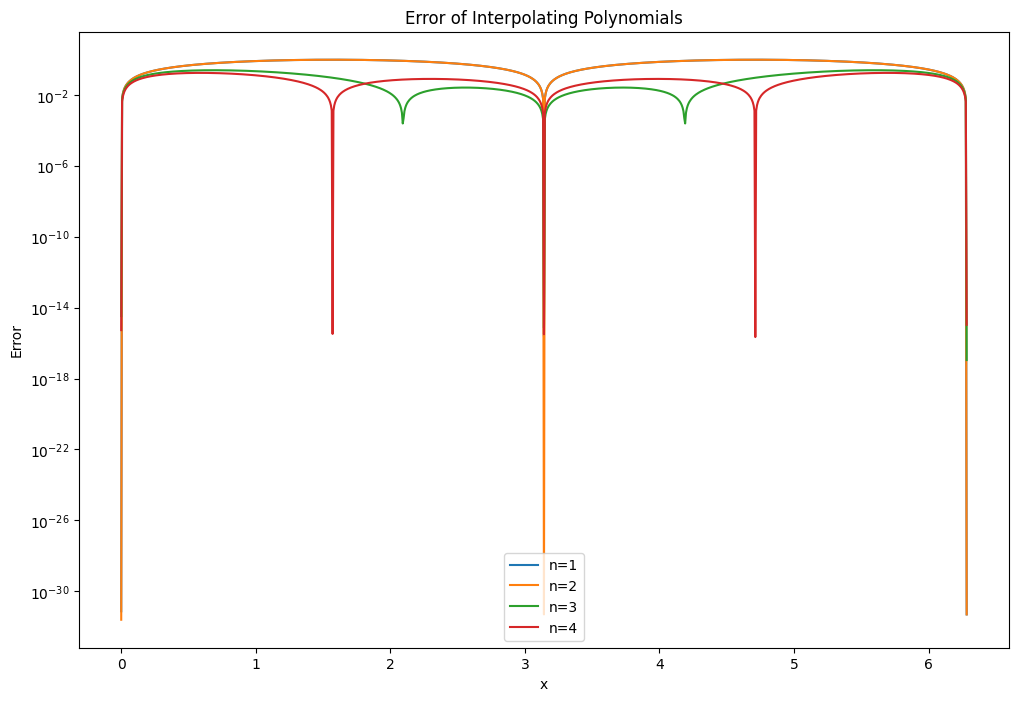

In [ ]:
# Discussion question A.1

# use "lambda functions" to define simple functions, e.g.:
#       f = lambda x: np.sin(x)
# This is equivalent to the standard function definition but more pythonic:
#       def f(x):
#           return np.sin(x)


# when calling evaluateInterpolant, you can use the following Xq array
points = int(1e3 + 1)
Xq = np.linspace(interval[0], interval[1], points)

f = lambda x: np.sin(x / p)
interval = np.array([a, b])
intervals = interval

# fix N = 1 and use a foor loop over n to add the 4 plots to the figure
plt.figure(figsize=(12, 8))

# for n in range(...) :
#    etc.

for n in range(4):
    coeffs = lagrangeInterp(f, interval, n+1)
    interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)
    plt.plot(Xq, interPol, label=f'n={n+1}')

# add the the original function to the plot for comparison
# don't forget labelling your plot to improve readability
# useful functions: plt.title plt.xlabel plt.ylabel plt.legend


plt.plot(Xq, f(Xq),linestyle='dashed', label='f(x)' )
plt.legend()
plt.xlabel('x')
plt.ylabel('Interpolated f(x)')
plt.title('Lagrange Interpolants')
plt.show()


# compute the 4 global errors and plot them using the same strategy
# you used before

plt.figure(figsize=(12, 8))
# your code ...
for n in range(4):
  coeffs = lagrangeInterp(f, interval, n+1)
  interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)
  error = np.abs(f(Xq) - interPol)
  plt.semilogy(Xq, error, label=f'n={n+1}')

plt.legend()
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Error of Interpolating Polynomials')
plt.show()
plt.show()

In [ ]:
# Discussion question A.1: (2 point(s), see also Tutorial: A.2)
# For each value of n, at how many points is the error between interpolant and function (very
# close to) zero in the plots? How can this number of points be explained from the theory?

#In the plot, for n = 1 and n = 2 we can see that the error between the function and the interpolant is (very close to)
#zero at 3 points. For n = 3 and n = 4 the error is close to zero at 5 points.


## discussion question A2

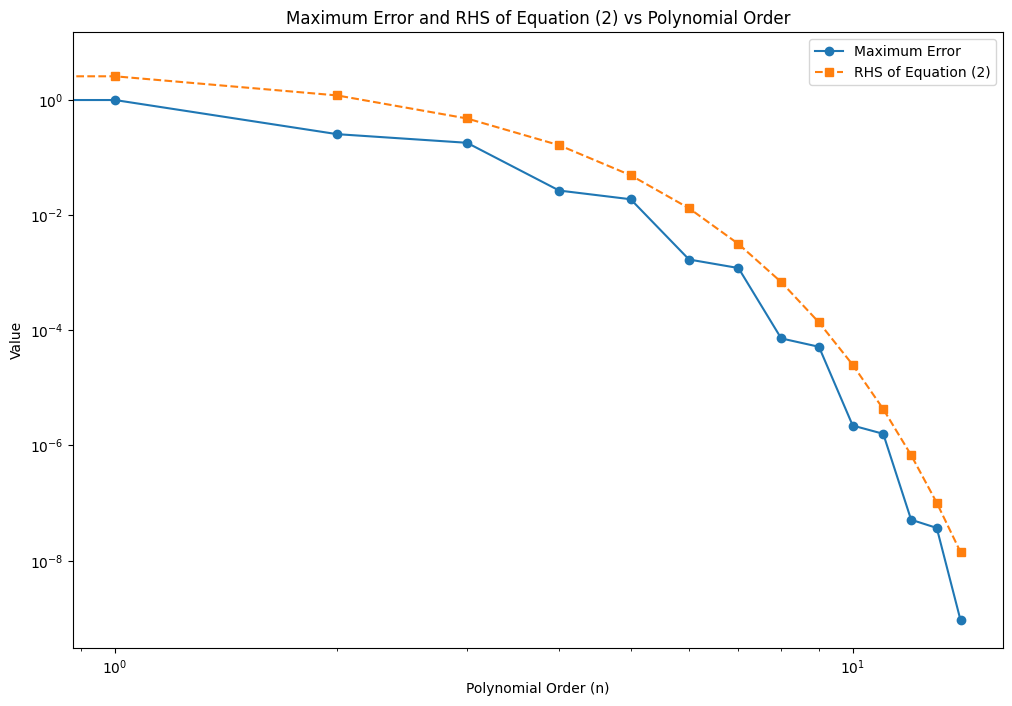

In [ ]:
## Discussion question A.2

# strategy: inside a for loop, compute coefficients, evaluate interpolant
# for n = 1,...,15 and save the corresponding value of the maximum error and
# rhs of Equation (2)

# plot the 2 curves in the same figure
# don't forget labelling your plot to improve readability
# useful functions: plt.title plt.xlabel plt.ylabel plt.legend

plt.figure(figsize=(12, 8))
f = lambda x: np.sin(x / p)
interval = np.array([a, b])
intervals = interval
# your code ...

maxErrors = np.zeros(15)
rhsValues = np.zeros(15)

for n in range(15):
    coeffs = lagrangeInterp(f, interval, n+1)
    interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)

    error = np.abs(f(Xq) - interPol)
    maxErrors[n] = np.max(error)

    #rhs of equation (2)
    numerator = np.abs(1 / p ** (n + 2))
    denominator = 4 * (n+2)
    rhsValues[n] = numerator / denominator * ((intervals[1] - intervals[0]) / (n+1) ) ** (n+2)


plt.loglog(range(15), maxErrors, marker='o', label='Maximum Error')
plt.loglog(range(15), rhsValues, marker='s', linestyle='dashed', label='RHS of Equation (2)')
plt.legend()
plt.xlabel('Polynomial Order (n)')
plt.ylabel('Value')
plt.title('Maximum Error and RHS of Equation (2) vs Polynomial Order')
#plt.grid(True)
plt.show()


In [ ]:
# Discussion question A.2: (2 point(s), see also Tutorial: A.4)
# Which of both curves (true error and right-hand-side of Equation (2)) is larger? How can this
# be explained from the theory?

# The right-hand-sight of Equation(2) is larger in the plot. This also checks out with the theory,
# since the right-hand-side is a bound for the maximum error.

# **B. Piecewise interpolation and stability analysis**

In [ ]:
## Piecewise interpolation
#
# INPUT:
# f             f scalar-valued function
# interval      interpolation interval [a, b]
# n             interpolation order
# N             number of subintervals
#
# OUTPUT:
# coeffs        multidimensional array, i-th element is an array containing the
#               centered coefficients of i-th subinterval (you can do it also with lists)
# intervals     multidimensional array, i-th element is an array containing the
#               beginning and endpoint of i-th subinterval (you can do it also with lists)



def piecewiseInterp(f, interval, n, N):
    # strategy: loop over the intervals, at each step update the output variables
    # defining the subinterval boundaries and then using lagrangeInterp over said
    # subinterval

    H = (interval[1] - interval[0]) / N
    coeffs = np.empty((N, n+1))
    intervals = np.empty((N, 2))

    for i in range(N):
        subintervalStart = interval[0] + i * H
        subintervalEnd = interval[0] + (i+1) * H

        subinterval = np.array((subintervalStart,subintervalEnd))
        intervals[i] = subinterval

        coeff = lagrangeInterp(f, intervals[i], n)
        coeffs[i] = coeff

        subintervalStart = subintervalEnd

    #in order to give us a single array for N=1 and a matrix for greater Ns
    if N == 1:
        return coeffs[0], intervals[0]
    else:
        return coeffs, intervals


    # consider precomputing the subinterval length (it should be easy as the interval is
    # split in N equally spaced subintervals...)

    # IMPORTANT: for N = 1 piecewiseInterp must be equivalent to lagrangeInterp
    # this will be checked by the TA

#print(piecewiseInterp(f, interval, n, N))

interval = np.array([a, b])
n = 3
N = 1

coeffs, intervals = piecewiseInterp(f, interval, n, N)
print("The i-th row are centered coefficients of i-th subinterval:")
print(coeffs)
print()
print("The i-th row are begin and endpoint of i-th subinterval:")
print(intervals)

The i-th row are centered coefficients of i-th subinterval:
[ 9.42659374e-02 -1.26488503e-16 -9.30367511e-01 -6.04915045e-16]

The i-th row are begin and endpoint of i-th subinterval:
[0.         6.28318531]


In [ ]:
print("Subinterval boundaries:")
print(intervals)
print("Coefficients for each subinterval:")
for i, coeff in enumerate(coeffs):
    print(f"Subinterval {i+1}: {coeff}")

Subinterval boundaries:
[0.         6.28318531]
Coefficients for each subinterval:
Subinterval 1: 0.09426593743935517
Subinterval 2: -1.2648850293916753e-16
Subinterval 3: -0.9303675110242734
Subinterval 4: -6.049150446058862e-16


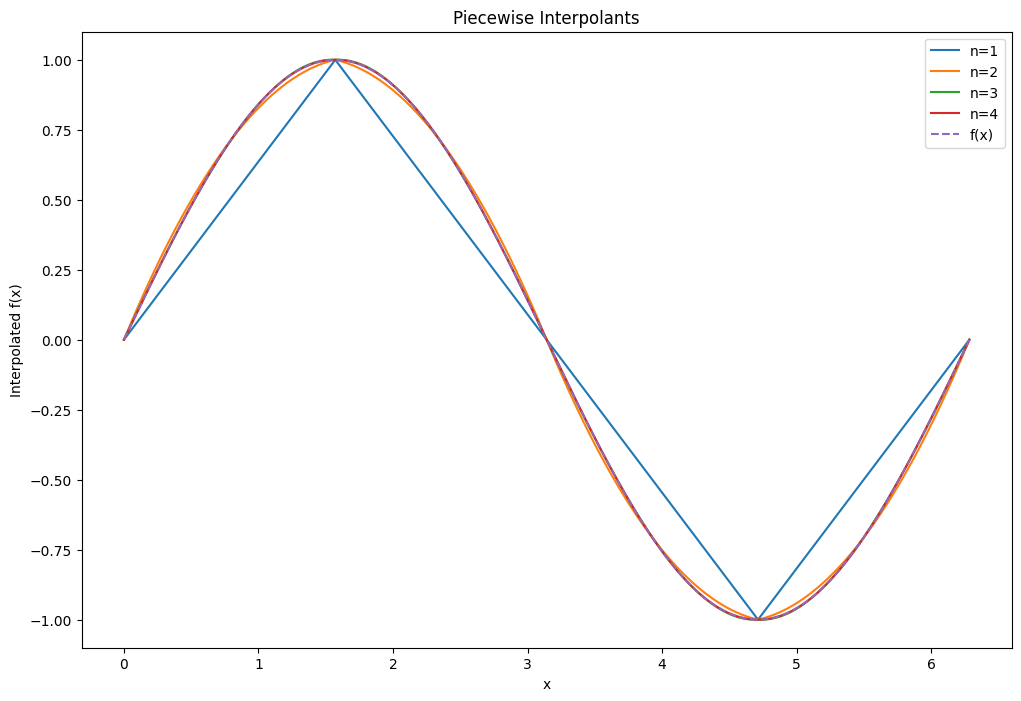

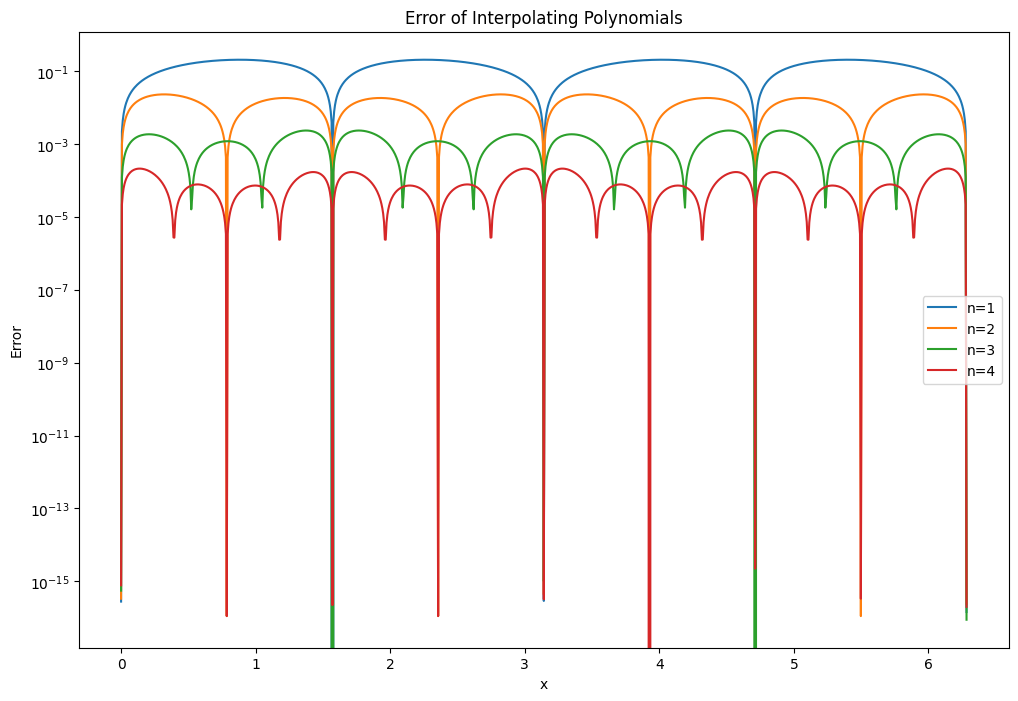

In [ ]:
## Repeat the exercise in A.1
f = lambda x: np.sin(x / p)
interval = np.array([a, b])

# you the following array
points = int(1e3 + 1)
Xq = np.linspace(interval[0], interval[1], points)


plt.figure(figsize=(12, 8))

# plot the piecewise interpolants for orders 1, 2, 3, 4 with N = 4
for n in range(4):
 coeffs, intervals = piecewiseInterp(f, interval, n+1, 4)
 interPol = evaluateInterpolant(coeffs, intervals, Xq, 4)
 plt.plot(Xq, interPol, label=f'n={n+1}')


plt.plot(Xq, f(Xq), linestyle='dashed', label='f(x)' )
plt.legend()
plt.xlabel('x')
plt.ylabel('Interpolated f(x)')
plt.title('Piecewise Interpolants')
plt.show()

# error as a function of x, for the piecewise interpolants with n = 1, ..., 4 at a fixed number of subintervals N = 4.
plt.figure(figsize=(12, 8))

for n in range(4):
  coeffs, intervals = piecewiseInterp(f, interval, n+1, 4)
  interPol = evaluateInterpolant(coeffs, intervals, Xq, 4)
  error = np.abs(f(Xq) - interPol)
  plt.semilogy(Xq, error, label=f'n={n+1}')

plt.legend()
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Error of Interpolating Polynomials')
plt.show()


## discussion question B1

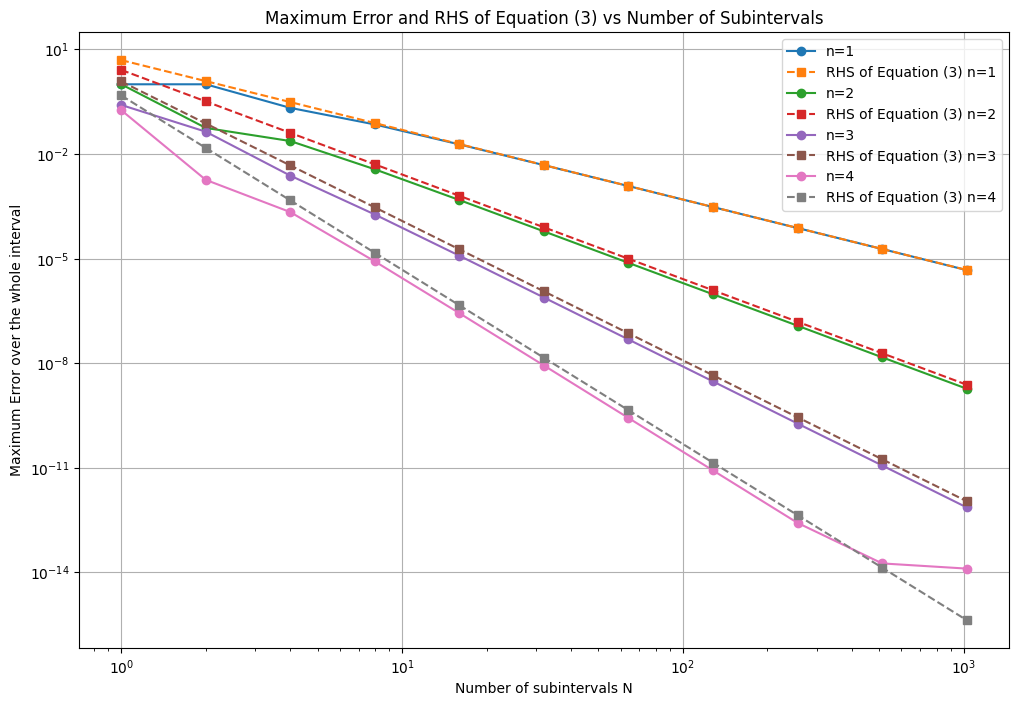

In [ ]:
## Discussion question B.1

# same strategy as for A.2 but notice that this time you have a multidimensional variable
# (it depends on n and N), so your for loop is a bit more complex...

#  plot the maximum error over the whole interval v/s the number of subintervals
plt.figure(figsize=(12, 8))


maxErrors = np.zeros((4,11))
rhsValues = np.zeros((4,11))

for n in range(4):

    for l in range(11):
        N = 2 ** l

        coeffs, intervals = piecewiseInterp(f, interval, n+1, N)
        interPol = evaluateInterpolant(coeffs, intervals, Xq, N)

        error = np.abs(f(Xq) - interPol)
        maxErrors[n,l] = np.max(error)

        numerator = np.abs(1 / p ** (n + 2))
        denominator = 4 * (n+2)
        rhsValues[n,l] = numerator / denominator * ( (interval[1] - interval[0]) / (N * (n+1)) ) ** (n+2)

    plt.loglog(2 ** np.arange(11), maxErrors[n,:], marker='o', label=f'n={n+1}')
    plt.loglog(2 ** np.arange(11) , rhsValues[n,:], marker='s', linestyle='dashed', label='RHS of Equation (3) ' f'n={n+1}')

plt.legend()
plt.xlabel('Number of subintervals N')
plt.ylabel('Maximum Error over the whole interval')
plt.title('Maximum Error and RHS of Equation (3) vs Number of Subintervals')
plt.grid(True)
plt.show()


In [ ]:
# Discussion question B.1: (2 point(s), see also Tutorial: B.7)
# For fixed n, each of the error curves ENnf should result in (approximately) a straight line as
# a function of N in the double logarithmic plot. Explain that in view of the theory, and in
# particular why the slope of that lines changes with changing n. Show the error curves for
#n = 1, 2, 3, 4 in the same plot.

#The error curves are bounded by the rhs(3), which are straight lines on the log axis.
#Moreover, the slope of the lines gets steeper as n increases(it can be easily seen by differentiating the bounds).


## discussion question B2

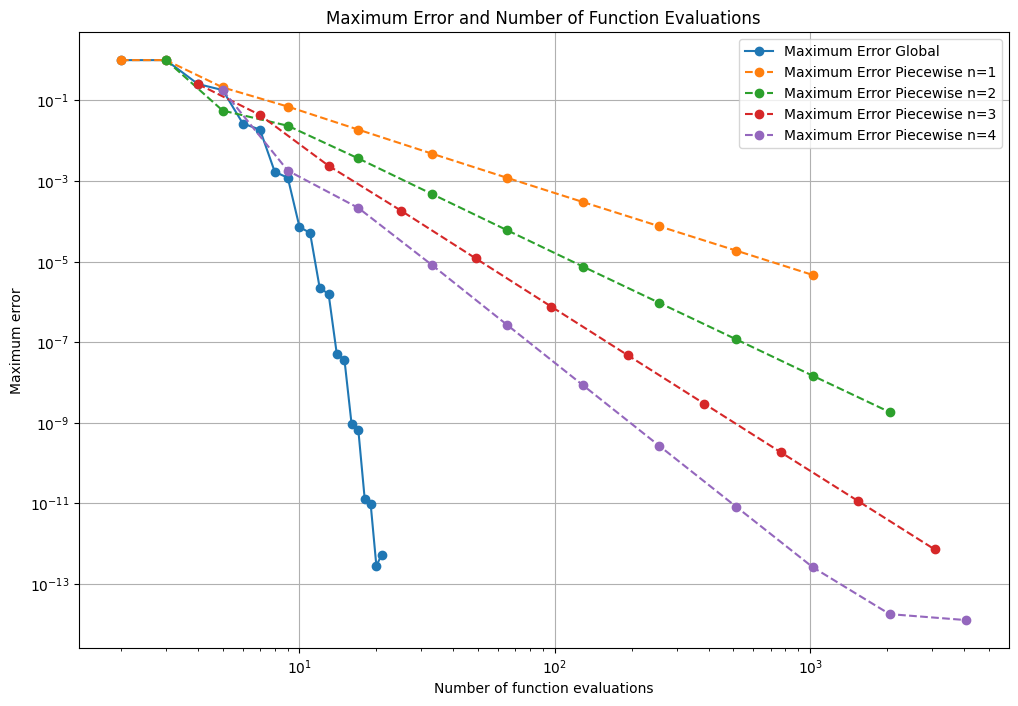

In [ ]:
## Discussion question B.2

# if you implemented the previous parts of code, this should be quick

plt.figure(figsize=(12, 8))
interval = np.array([a, b])
intervals = interval

# curve for the maximum (global) Lagrange interpolation error
maxErrorsGlobal = np.zeros(20)
funcEvalsGlobal = np.arange(1,21) + 1
for n in range(20):
    coeffs = lagrangeInterp(f, interval, n+1)
    interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)

    error = np.abs(f(Xq) - interPol)
    maxErrorsGlobal[n] = np.max(error)

plt.loglog(funcEvalsGlobal, maxErrorsGlobal, marker='o', label='Maximum Error Global')

# curve for each n = 1,...,4: the maximum piecewise Lagrange interpolation error
maxErrorsPiecewise = np.zeros((4,11))
funcEvalsPiecewise = (2 ** np.arange(11)) * np.arange(1, 5)[:, np.newaxis] + 1
for n in range(4):
    for l in range(11):
        N = 2 ** l

        coeffs, intervals = piecewiseInterp(f, interval, n+1, N)
        interPol = evaluateInterpolant(coeffs, intervals, Xq, N)

        error = np.abs(f(Xq) - interPol)
        maxErrorsPiecewise[n,l] = np.max(error)

    plt.loglog(funcEvalsPiecewise[n,:], maxErrorsPiecewise[n,:], marker='o', linestyle= 'dashed', label='Maximum Error Piecewise ' f'n={n+1}')

plt.legend()
plt.xlabel('Number of function evaluations')
plt.ylabel('Maximum error')
plt.title('Maximum Error and Number of Function Evaluations')
plt.grid(True)
plt.show()


In [ ]:
# Discussion question B.2: (3 point(s), see also Tutorial: A.4, B.7, B.9)
# (a) Which method of increasing the interpolation accuracy leads to a smaller number of
# function evaluations for a given accuracy? Justify your answer using the error estimation (3)

# The global Lagrange interpolation leads to a smaller number of evaluations in this case.
# This is because in the global case we have n + 1 = 21 evaluations and for the piecwise we,
# for n =1, the maximum number of evalutaions is N + 1 = 2^{10} + 1 which is clearly more. This
# is true for all n= 1, 2, 3, 4. However, if we increase n even more it might happen that at some point
# the slopes are going to get steeper and the error is going to tend to 0 faster than in the global case.

## discussion question B3

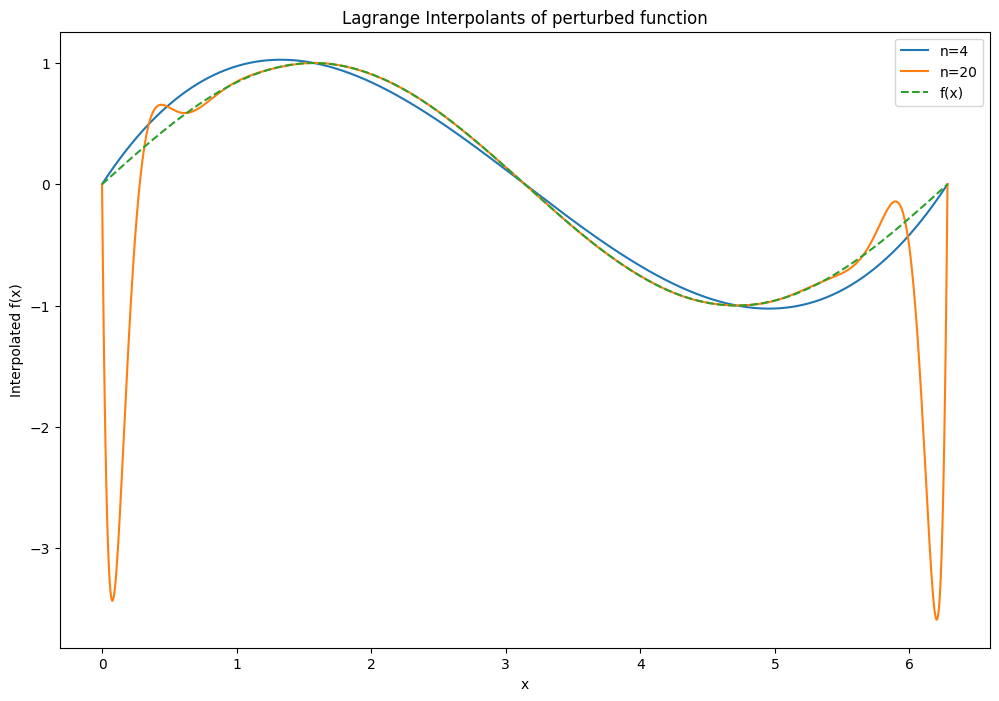

In [ ]:
# Global interpolation of perturbed f

# repeat what you did in A.1 but using the perturbed function
f = lambda x: np.sin(x / p)
fPer = lambda x: f(x) + (1e-3 * np.cos(8 * x / p))
ns=[4, 20]

points = int(1e3 + 1)
Xq = np.linspace(interval[0], interval[1], points)
interval = np.array([a, b])
intervals = interval


plt.figure(figsize=(12, 8))


for i in range(2):
  coeffs = lagrangeInterp(fPer, interval, ns[i])
  interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)
  plt.plot(Xq, interPol, label=f'n={ns[i]}')


plt.plot(Xq, f(Xq), linestyle = 'dashed', label='f(x)' )
plt.legend()
plt.xlabel('x')
plt.ylabel('Interpolated f(x)')
plt.title('Lagrange Interpolants of perturbed function')
plt.show()

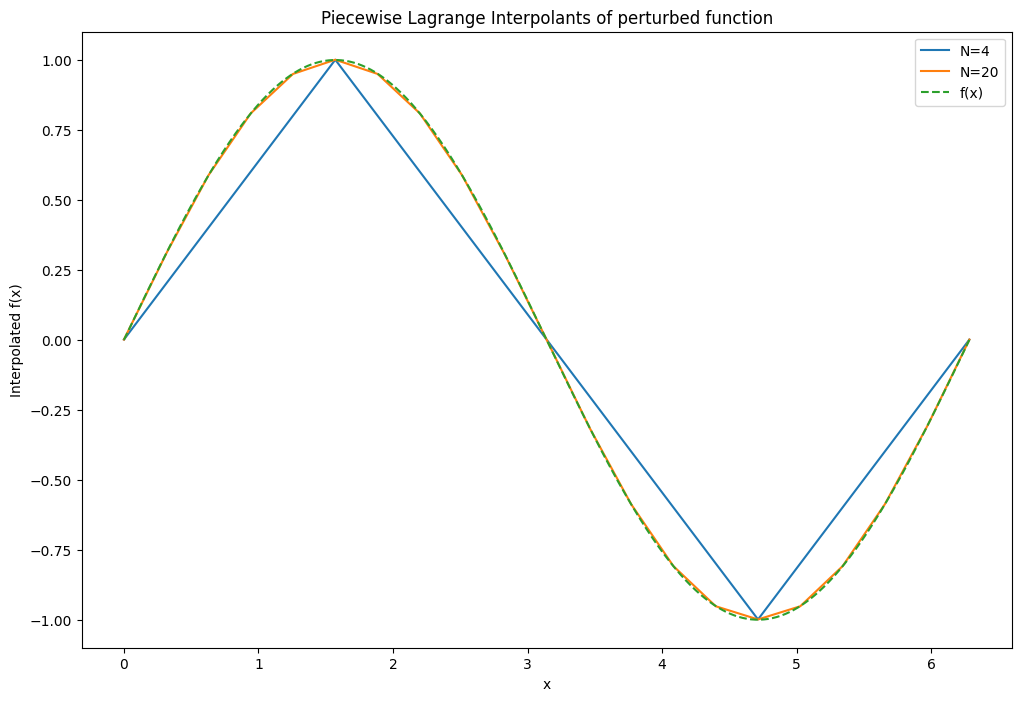

In [ ]:
# Piecewise interepolation of perturbed f

# repeat what you did before but using piecewise interpolation with n = 1,
# N = 4 subintervals AND N = 20 subintervals
Ns = [4, 20]

interval = np.array([a, b])
intervals = interval

plt.figure(figsize=(12, 8))

for i in range(2):
  coeffsPiecewise, intervals = piecewiseInterp(fPer, interval, 1, Ns[i])
  interPolPiecewise = evaluateInterpolant(coeffsPiecewise, intervals, Xq, Ns[i])
  plt.plot(Xq, interPolPiecewise, label=f'N={Ns[i]}')

plt.plot(Xq, f(Xq),linestyle = 'dashed', label='f(x)' )
plt.legend()
plt.xlabel('x')
plt.ylabel('Interpolated f(x)')
plt.title('Piecewise Lagrange Interpolants of perturbed function')
plt.show()

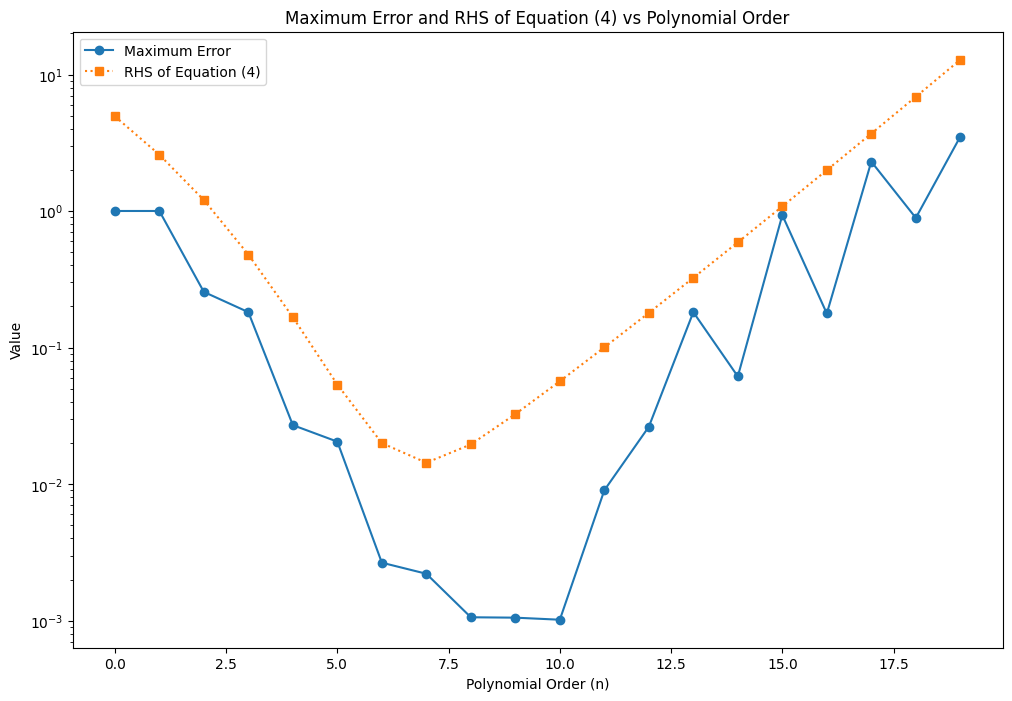

In [ ]:
## Discussion question B.3 (a)

# repeat A.2 using the perturbed function

# you can define the rhs of (4) using the previously introduced "lambda functions"
# depending on n and then call the resulting functions inside the loop
# if you need the "lambda function" to depend on more variables, just add them
# before the : separated by commas, e.g.: y = lambda n, x, t: ...
# if it's easier for you, stick to the standard function definition
# def rhs(n, x, t):
#   ...
#   return rhs_value

#for simplicity, define the rhs of (5) and note that for N=1 it is equal to the rhs of (4)
rhs = lambda n, xVals, N: ( ( np.abs(1 / p ** (n + 1)) / (4 * (n+1)) ) * ( (interval[1] - interval[0]) / (N * n) )  ** (n+1) ) + ( ( (2 ** (n+1))/ ((np.e * n * np.log(n)) + np.euler_gamma) ) * np.max(np.abs((fPer(xVals)-f(xVals)))))

plt.figure(figsize=(12, 8))

interval = np.array([a, b])
intervals = interval


maxErrors = np.zeros(20)
rhsValues = np.zeros(20)

for n in range(20):
    coeffs = lagrangeInterp(fPer, interval, n+1)
    interPol = evaluateInterpolant(coeffs, intervals, Xq, 1)

    error = np.abs(f(Xq) - interPol)
    maxErrors[n] = np.max(error)

    rhsValues[n] = rhs(n+1, Xq, 1)

# you're asked to use plt.semilogy to plot your results
plt.semilogy(range(20), maxErrors, marker='o', label='Maximum Error')
plt.semilogy(range(20), rhsValues, marker='s', linestyle='dotted', label='RHS of Equation (4)')
plt.legend()
plt.xlabel('Polynomial Order (n)')
plt.ylabel('Value')
plt.title('Maximum Error and RHS of Equation (4) vs Polynomial Order')
#plt.grid(True)
plt.show()


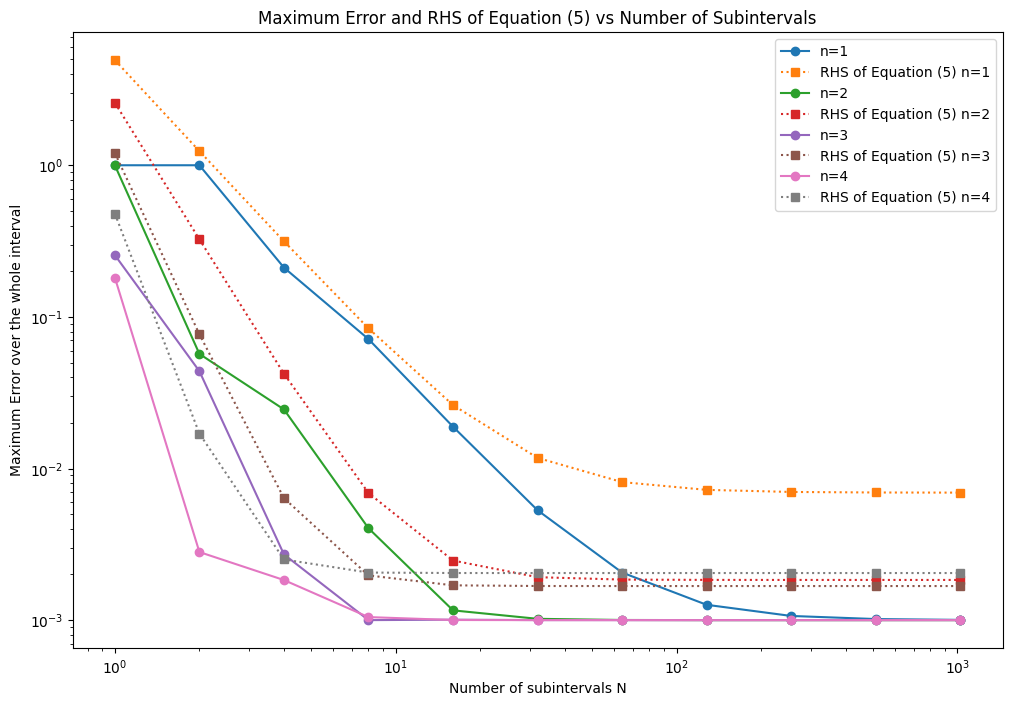

In [ ]:
## Discussion question B.3 (b)

# same strategy as in A.3

plt.figure(figsize=(12, 8))

interval = np.array([a, b])
intervals = interval


maxErrors = np.zeros((4,11))
rhsValues = np.zeros((4,11))

for n in range(4):

    for l in range(11):
        N = 2 ** l

        coeffs, intervals = piecewiseInterp(fPer, interval, n+1, N)
        interPol = evaluateInterpolant(coeffs, intervals, Xq, N)

        error = np.abs(f(Xq) - interPol)
        maxErrors[n,l] = np.max(error)

        rhsValues[n,l] = rhs(n+1, Xq, N)

    plt.loglog(2 ** np.arange(11), maxErrors[n,:], marker='o', label=f'n={n+1}')
    plt.loglog(2 ** np.arange(11) , rhsValues[n,:], marker='s', linestyle='dotted', label='RHS of Equation (5) ' f'n={n+1}')

plt.legend()
plt.xlabel('Number of subintervals N')
plt.ylabel('Maximum Error over the whole interval')
plt.title('Maximum Error and RHS of Equation (5) vs Number of Subintervals')
plt.show()


In [ ]:
# Discussion question B.3: (5 point(s), see also Tutorial: B.1, B.2, B.3)
# (a) Describe the behavior of maxx(Πnˆf(x) − f(x)) with respect to n and explain it in view
# of the theory.
# (b) Describe the behavior of maxx(ΠNnˆf(x) − f(x)) with respect to N and explain it in view
# of the theory.
# (c) In case that you would know that the “measured” function values are perturbed, but
# you just know that the perturbations correspond to random variables at each node every
# time, and therefore they will change every time you measure them, which combination
# of N and n would (most likely) lead to the a more similar error when repeating the
# measurements? Justify your answer in view of the theory.

#(a)
# Since the function is perturbed the error is going to grow as the order of n is increasing,
# whereas in the case where the function is not perturbed we saw that the error tends to zero.

#(b)
# The maximum error between the piecewise langrange interpolation of the perturbed function and
# the function f(x) still tends to zero as in the case where f is not perturbed, but much slower.
# Hence we see that if we are dealing with a perturbed function, the most convinient interpolation
# is the piecewise one.

#(c)
# Looking at the rhs(5) we want to minimize it as much as possible. We have that \Lambda_n (Lebesgue constant) is dependent
# the order n. It is the quotient of an exponential and a logarithmic function so we can compute its minimum and obtain n = 3.
# But we also need the first term in the sum to be very small, and since we already have to take n to be 3, N has to as big
# as possible.




# **C. Integration**

In [ ]:
## Composite integration
#
# INPUT
# f                 f scalar-valued function
# interval          interpolation interval [a, b]
# n                 interpolation order
# N                 number of subintervals
#
# OUTPUT
# num_integral      approximate integral


def compositeIntegr(f, interval, n, N):
    # if your piecewiseLagrange works correctly for all N,
    # then this function should'nt be complex to implement...

    numIntegral = 0

    coeffs, intervals = piecewiseInterp(f, interval, n, N)

    for i in range(N):
        if N == 1:
            x0 = interval[0]
            x1 = interval[1]

            m = (x0 + x1) / 2

            for j in range(n+1):
                numIntegralx0 = (coeffs[j] / (n + 1 - j)) * ((x0 - m) ** (n + 1 - j))
                numIntegralx1 = (coeffs[j] / (n + 1 - j)) * ((x1 - m) ** (n + 1 - j))
                numIntegralDiff = numIntegralx1 - numIntegralx0
                numIntegral = numIntegral + numIntegralDiff

        else:
            x0 = intervals[[i], [0]]
            x1 = intervals[[i], [1]]

            m = (x0 + x1) / 2

            for j in range(n+1):
                numIntegralx0 = (coeffs[i,j] / (n + 1 - j)) * ((x0 - m) ** (n + 1 - j))
                numIntegralx1 = (coeffs[i,j] / (n + 1 - j)) * ((x1 - m) ** (n + 1 - j))
                numIntegralDiff = numIntegralx1 - numIntegralx0
                numIntegral = numIntegral + numIntegralDiff

    return numIntegral

f = lambda x: np.sin(x / p)
interval = np.array([a, b])
print(compositeIntegr(f, np.array([5,10]), 7, 2))


[1.12273456]


## discussion question C1

In [ ]:
## Discussion question C.1

# IMPORTANT: you have to give a numerical example that confirms what the definition says ...
# the functions you use are up to you, pick the simplest possible

#for n = 1 in compositeIntegr we get trapezoidal
def trapezoidalIntegr(f, interval):
    trapIntegral = ( (interval[1] - interval[0]) / 2 ) * ( f(interval[0]) + f(interval[1]) )
    return trapIntegral

#for n = 2 in compositeIntegr we get simpson
def simpsonIntegr(f, interval):
    m = (interval[0] + interval[1]) / 2
    simpIntegr = ( (interval[1] - interval[0]) / 6 ) * ( f(interval[0]) + (4 * f(m)) + f(interval[1]) )
    return simpIntegr


interval = np.array([a, b])

poly1 = lambda x: x
poly1Integr = lambda x: (1/2) * (x ** 2)

poly2 = lambda x: x ** 2
poly2Integr = lambda x: (1/3) * (x ** 3)

poly3 = lambda x: x ** 3
poly3Integr = lambda x: (1/4) * (x ** 4)

poly4 = lambda x: x ** 4
poly4Integr = lambda x: (1/5) * (x ** 5)


print("degree 1")
print("Exact Integral =", poly1Integr(interval[1]) - poly1Integr(interval[0]) )
print("Approximate Integral (n=1) =", compositeIntegr(poly1, interval, 1, 1))
#print("Trapezoidal formula (poly1) =", trapezoidalIntegr(poly1, interval))
print("Approximate Integral (n=2) =", compositeIntegr(poly1, interval, 2, 1))
#print("Simpson’s formula (poly1) =", simpsonIntegr(poly1, interval))
print()
print("degree 2")
print("Exact Integral =", poly2Integr(interval[1]) - poly2Integr(interval[0]) )
print("Approximate Integral (n=1) =", compositeIntegr(poly2, interval, 1, 1))
#print("Trapezoidal formula (poly2) =", trapezoidalIntegr(poly2, interval))
print("Approximate Integral (n=2) =", compositeIntegr(poly2, interval, 2, 1))
#print("Simpson’s formula (poly2) =", simpsonIntegr(poly2, interval))
print()
print("dgree 3")
print("Exact Integral =", poly3Integr(interval[1]) - poly3Integr(interval[0]) )
print("Approximate Integral (n=1) =", compositeIntegr(poly3, interval, 1, 1))
#print("Trapezoidal formula (poly3) =", trapezoidalIntegr(poly3, interval))
print("Approximate Integral (n=2) =", compositeIntegr(poly3, interval, 2, 1))
#print("Simpson’s formula (poly3) =", simpsonIntegr(poly3, interval))
print()
print("degree 4")
print("Exact Integral =", poly4Integr(interval[1]) - poly4Integr(interval[0]) )
print("Approximate Integral (n=1) =", compositeIntegr(poly4, interval, 1, 1))
#print("Trapezoidal formula (poly4) =", trapezoidalIntegr(poly4, interval))
print("Approximate Integral (n=2) =", compositeIntegr(poly4, interval, 2, 1))
#print("Simpson’s formula (poly4)=", simpsonIntegr(poly4, interval))


degree 1
Exact Integral = 19.739208802178716
Approximate Integral (n=1) = 19.73920880217872
Approximate Integral (n=2) = 19.739208802178712

degree 2
Exact Integral = 82.68340448079951
Approximate Integral (n=1) = 124.0251067211993
Approximate Integral (n=2) = 82.68340448079951

dgree 3
Exact Integral = 389.63636413600966
Approximate Integral (n=1) = 779.2727282720197
Approximate Integral (n=2) = 389.63636413600955

degree 4
Exact Integral = 1958.5259826258011
Approximate Integral (n=1) = 4896.3149565645035
Approximate Integral (n=2) = 2040.131231901875


In [ ]:
# Discussion question C.1: (2 point(s), see also Tutorial: C.4, C.5)
# Give a few numerical examples using the function compositeIntegr you have just implemented
# to show that the Trapezoidal and Simpson’s rules have degree of exactness 1 and 3 respectively.
# Justify your answer referring to the theory.

# The Trapezoidal and Simpon's rules are defined in the above code and they are equal to
# the integral of the Lagrange interpolation of orders 1 and 2 respecively by C4(a) and C5(a).
# For the Trapezoidal rule, the degree of exactness is 1, since equality holds for x, but not
# for x^2. Similiarly, the degree of exactness for Simpson's rule is 3, since equality holds
# for x^3, but not for x^4.

## discussion question C2

<ipython-input-640-70e1db300095>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  numIntegral[n,l] = compositeIntegr(k, interval, n+1, N)


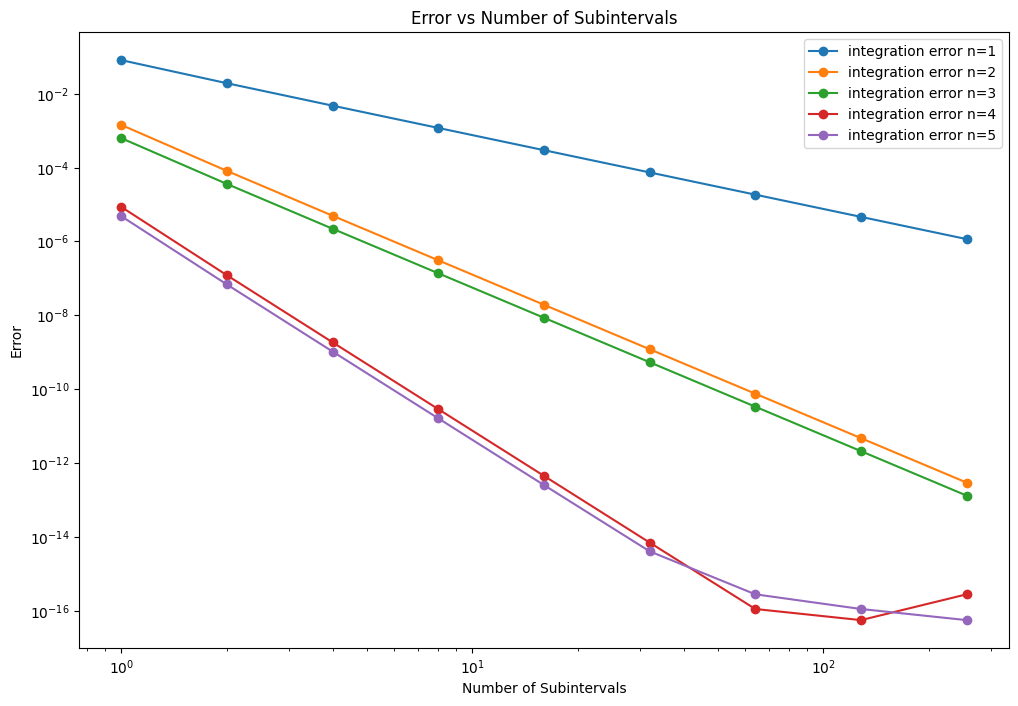

In [ ]:
## Discussion question C.2

# strategy: loop over n = 1,...,5 and for each value of n compute errors and order
# then plot

k = lambda x: (np.sin(x)) ** 2

interval = np.array([0, 1])
numIntegral = np.zeros((5,9))
integrationError = np.zeros((5,9))


plt.figure(figsize=(12, 8))

for n in range(5):

    for l in range(9):
        N = 2 ** l
        numIntegral[n,l] = compositeIntegr(k, interval, n+1, N)
        integrationError[n, l] = np.abs(((1 - (np.cos(1) * np.sin(1))) / 2) - numIntegral[n,l] )

    plt.loglog(2 ** np.arange(9), integrationError[n,:], marker='o', label='integration error ' f'n={n+1}')


plt.legend()
plt.xlabel('Number of Subintervals')
plt.ylabel('Error')
plt.title('Error vs Number of Subintervals')
#plt.grid(True)
plt.show()


In [ ]:
# Discussion question C.2: (3 point(s), see also Tutorial: C.4, C.5)
# (a) For each n = 1, . . . , 5: compute the approximate integral of f(x) = sin2(x) over the
# interval [0, 1] using N = 2^0,..., 2^8 intervals, and compute the error for each N. Plot
# using loglog the error as function of the number of subintervals for each n = 1,..., 5.
# (b) What could be the degree of exactness for each of the plotted values of n based on the
# error curves you just computed. How could you justify your answer from the theory?
# How could you test numerically if your hypothesis is correct?

#(a)
# Two plost above.

#(b)
# We already know that for n = 1 and n =2 the degree of exactness is 1 and 3 respectively.
# From the plot above we can see that the curve for n = 2 and n = 3 have the same slope so we
# claim that the degree of exactness for n = 3 is 3 as well. Similarly, for n = 4 and n = 5 also
# have the same slope so we assume that they have the same degree of exactness. Since the change
# in slopes from n = 1 to n = 2 is similar to the change in slopes from n = 2 to n = 4, we claim
# that the degree of exactness for n = 4 and n = 5 is equal to 5. This alligns with the theory, since
# we must have n <= d < 2(n + 1). To test our hypothesis nummerically, we assign the degrees n to
# our priviously implemented function compositeIntegr. For n = 3 we test that equality with the exact
# integral holds for a polynomial of degree 3, but not for degree 4, and for n = 4, 5, we check equality
# for a polynomial of degree 5, but not for degree 6.

In [ ]:
poly5 = lambda x: x ** 5
poly5Integr = lambda x: (1/6) * (x ** 6)
poly6 = lambda x: x ** 6
poly6Integr = lambda x: (1/7) * (x ** 7)

# for n = 3 the degree of exactness is 3
print("Claim: for n=3 the degree of exactness is 3")
print("degree 3")
print("Exact Integral =", poly3Integr(interval[1]) - poly3Integr(interval[0]) )
print("Approximate Integral (n=3) =", compositeIntegr(poly3, interval, 3, 1))

print("degree 4")
print("Exact Integral =", poly4Integr(interval[1]) - poly4Integr(interval[0]) )
print("Approximate Integral (n=3) =", compositeIntegr(poly4, interval, 3, 1))
print()

# for n = 4 the degree of exactness is 5
print("Claim: for n=4 the degree of exactness is 5")
print("degree 5")
print("Exact Integral =", poly5Integr(interval[1]) - poly5Integr(interval[0]) )
print("Approximate Integral (n=4) =", compositeIntegr(poly5, interval, 4, 1))

print("degree 6")
print("Exact Integral =", poly6Integr(interval[1]) - poly6Integr(interval[0]) )
print("Approximate Integral (n=4) =", compositeIntegr(poly6, interval, 4, 1))
print()

# for n = 5 the degree of exactness is 5
print("Claim: for n=5 the degree of exactness is 5")
print("degree 5")
print("Exact Integral =", poly5Integr(interval[1]) - poly5Integr(interval[0]) )
print("Approximate Integral (n=5) =", compositeIntegr(poly5, interval, 5, 1))

print("degree 6")
print("Exact Integral =", poly6Integr(interval[1]) - poly6Integr(interval[0]) )
print("Approximate Integral (n=5) =", compositeIntegr(poly6, interval, 5, 1))
print()

Claim: for n=3 the degree of exactness is 3
degree 3
Exact Integral = 0.25
Approximate Integral (n=3) = 0.25
degree 4
Exact Integral = 0.2
Approximate Integral (n=3) = 0.20370370370370366

Claim: for n=4 the degree of exactness is 5
degree 5
Exact Integral = 0.16666666666666666
Approximate Integral (n=4) = 0.16666666666666657
degree 6
Exact Integral = 0.14285714285714285
Approximate Integral (n=4) = 0.14322916666666655

Claim: for n=5 the degree of exactness is 5
degree 5
Exact Integral = 0.16666666666666666
Approximate Integral (n=5) = 0.16666666666666652
degree 6
Exact Integral = 0.14285714285714285
Approximate Integral (n=5) = 0.1430666666666667

